# treeArches: information-rich hierarchy plots

In this tutorial, we use the PBMC tree [basic treeArches tutorial](treeArches_pbmc.ipynb) to demonstrate new information-rich tree visualization methods with `scarches.plotting.plot_tree`. These plots show how an information-rich tree can aid in interpretation of treeArches results, by showing confidence of new cell types with their cell counts, presence/distribution across samples (sample diversity), study composition, and scHPL prediction confidence.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scanpy as sc
import scarches as sca
from scarches.plotting import plot_tree
import gdown
import matplotlib.pyplot as plt

sc.settings.verbosity = 0
# Crisp figures in Jupyter (retina / high-DPI backend)
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 120


 captum (see https://github.com/pytorch/captum).


## Reference latent space and hierarchy

The same workflow as [basic treeArches tutorial](treeArches_pbmc.ipynb) is used here for updating the tree. Here we subsample cells and use fewer epochs so the notebook is lightweight and we can focus on the visualization. Use the full run from the basic tutorial when you need the complete atlas hierarchy.

In [2]:
url = 'https://drive.google.com/uc?id=1LaYOadbotGC6gXAlo-aKfHz-spoFnawk'
if not os.path.exists('pbmc.h5ad'):
    gdown.download(url, 'pbmc.h5ad', quiet=False)

adata = sc.read('pbmc.h5ad')
adata.X = adata.layers['counts'].copy()
adata = adata[adata.obs.study != 'Villani'].copy()

target_conditions = ['10X']
source_adata = adata[~adata.obs.study.isin(target_conditions)].copy()
target_adata = adata[adata.obs.study.isin(target_conditions)].copy()

rng = np.random.RandomState(0)
n_ref, n_query = 4000, 1500
source_adata = source_adata[rng.choice(source_adata.n_obs, n_ref, replace=False)].copy()
target_adata = target_adata[rng.choice(target_adata.n_obs, n_query, replace=False)].copy()

source_adata.raw = source_adata
sc.pp.normalize_total(source_adata)
sc.pp.log1p(source_adata)
sc.pp.highly_variable_genes(
    source_adata, n_top_genes=2000, batch_key='batch', subset=True
)
source_adata.X = source_adata.raw[:, source_adata.var_names].X


In [3]:
sca.models.SCVI.setup_anndata(source_adata, batch_key='batch')
vae = sca.models.SCVI(
    source_adata,
    n_layers=2,
    encode_covariates=True,
    deeply_inject_covariates=True,
    use_layer_norm='both',
    use_batch_norm='none',
)
vae.train(max_epochs=40)

reference_latent = sc.AnnData(vae.get_latent_representation())
reference_latent.obs['cell_type'] = source_adata.obs['final_annotation'].tolist()
reference_latent.obs['batch'] = source_adata.obs['batch'].tolist()
reference_latent.obs['study'] = source_adata.obs['study'].tolist()
reference_latent.obs['celltype_batch'] = (
    np.asarray(reference_latent.obs['cell_type'].astype(str))
    + '-'
    + np.asarray(reference_latent.obs['study'].astype(str))
)

ref_path = 'ref_model/'
vae.save(ref_path, overwrite=True)


INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Epoch 40/40: 100%|█████| 40/40 [00:17<00:00,  2.42it/s, v_num=1, train_loss=429]

INFO: `Trainer.fit` stopped: `max_epochs=40` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 40/40: 100%|█████| 40/40 [00:17<00:00,  2.34it/s, v_num=1, train_loss=429]


Starting tree:


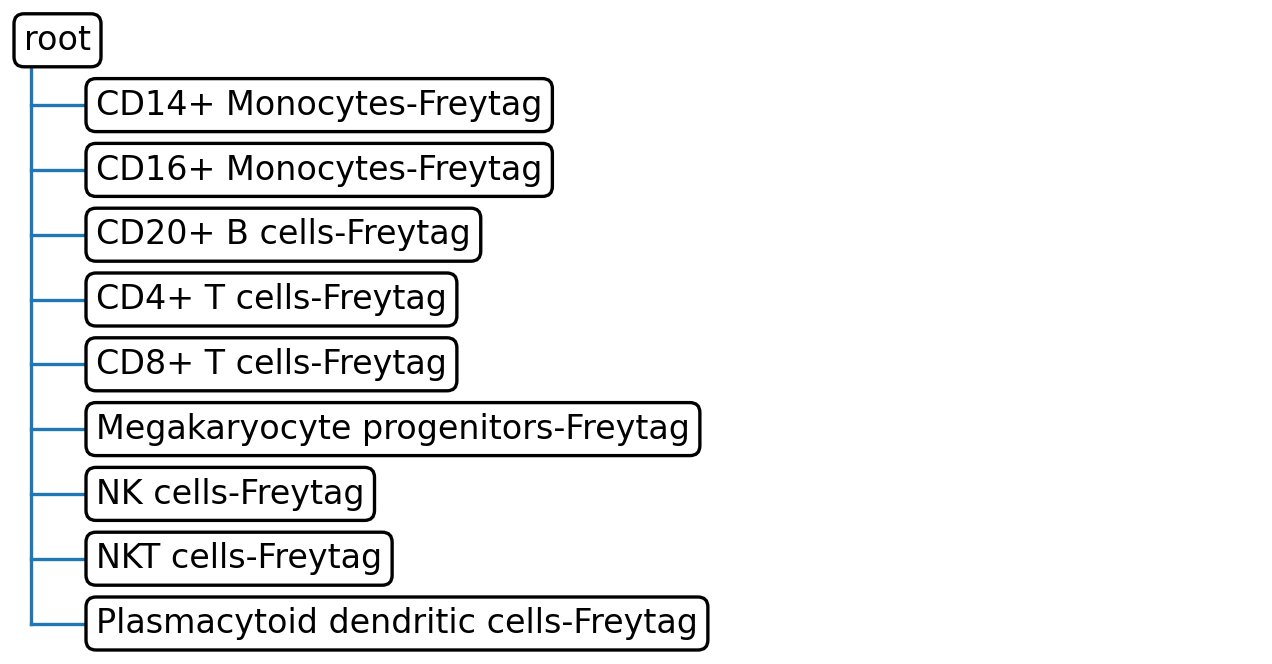


Adding dataset Oetjen to the tree
These populations are missing from the tree: 
['NK cells-Oetjen' 'NKT cells-Oetjen']

Updated tree:


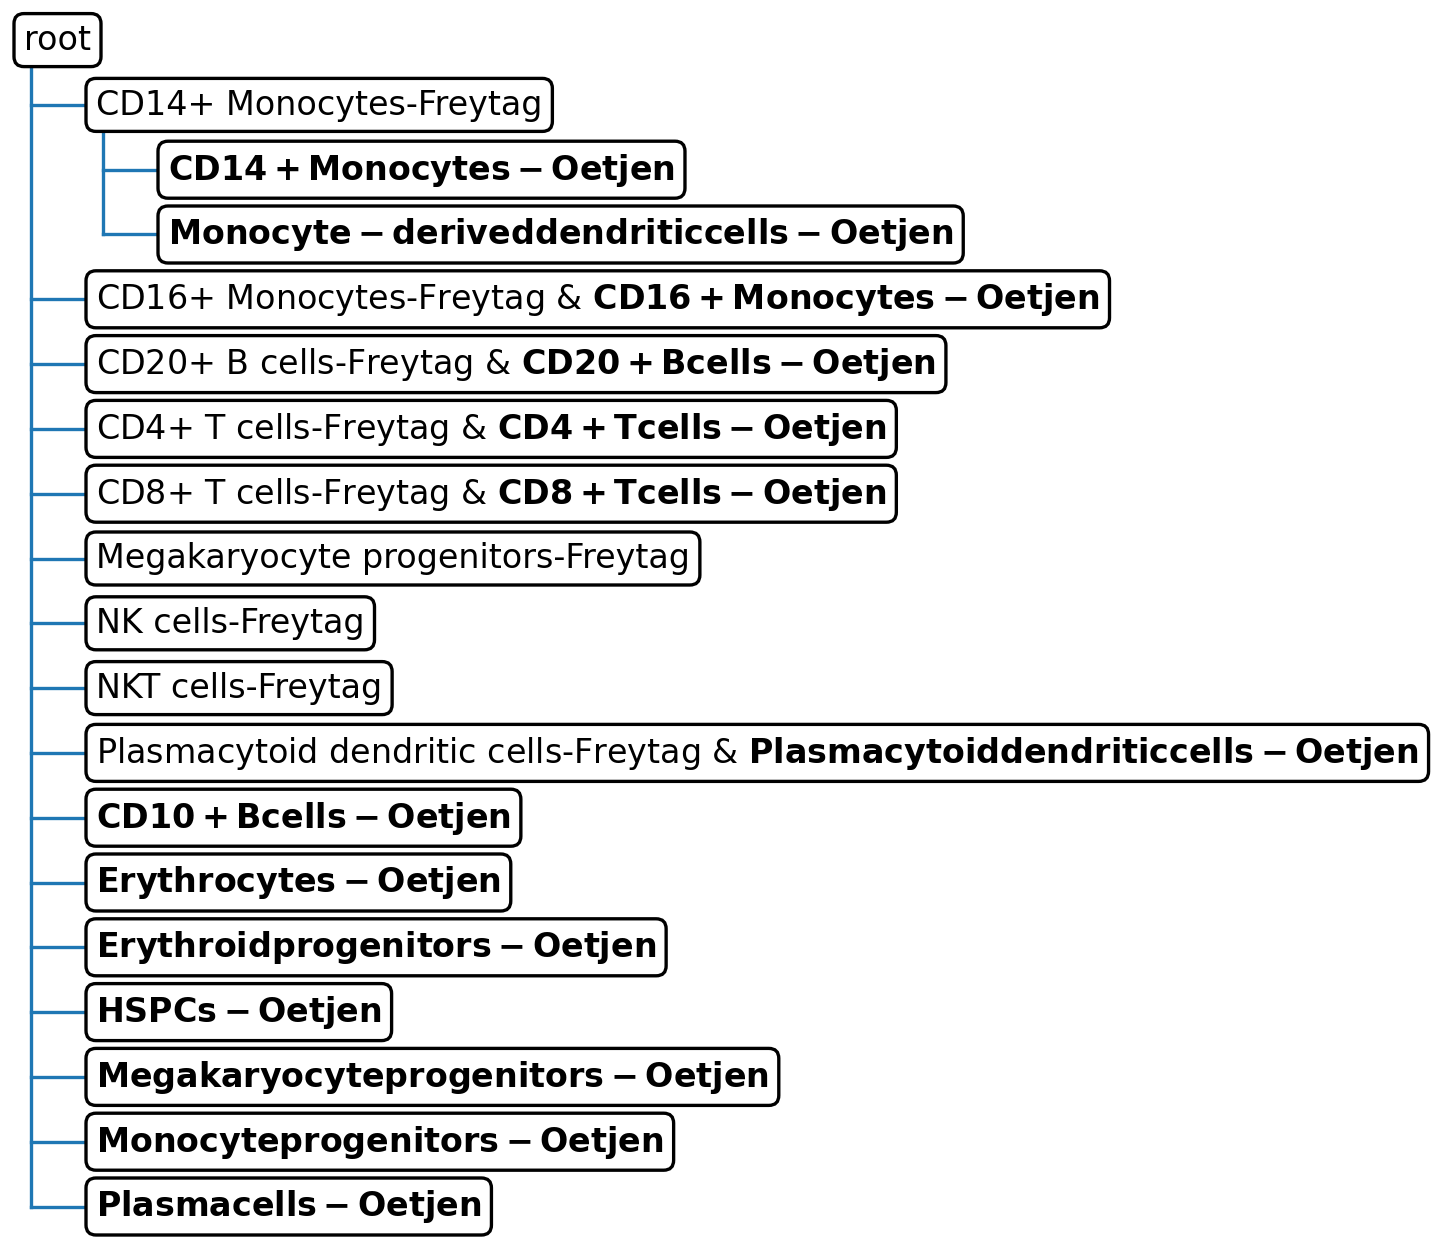


Adding dataset Sun to the tree

Updated tree:


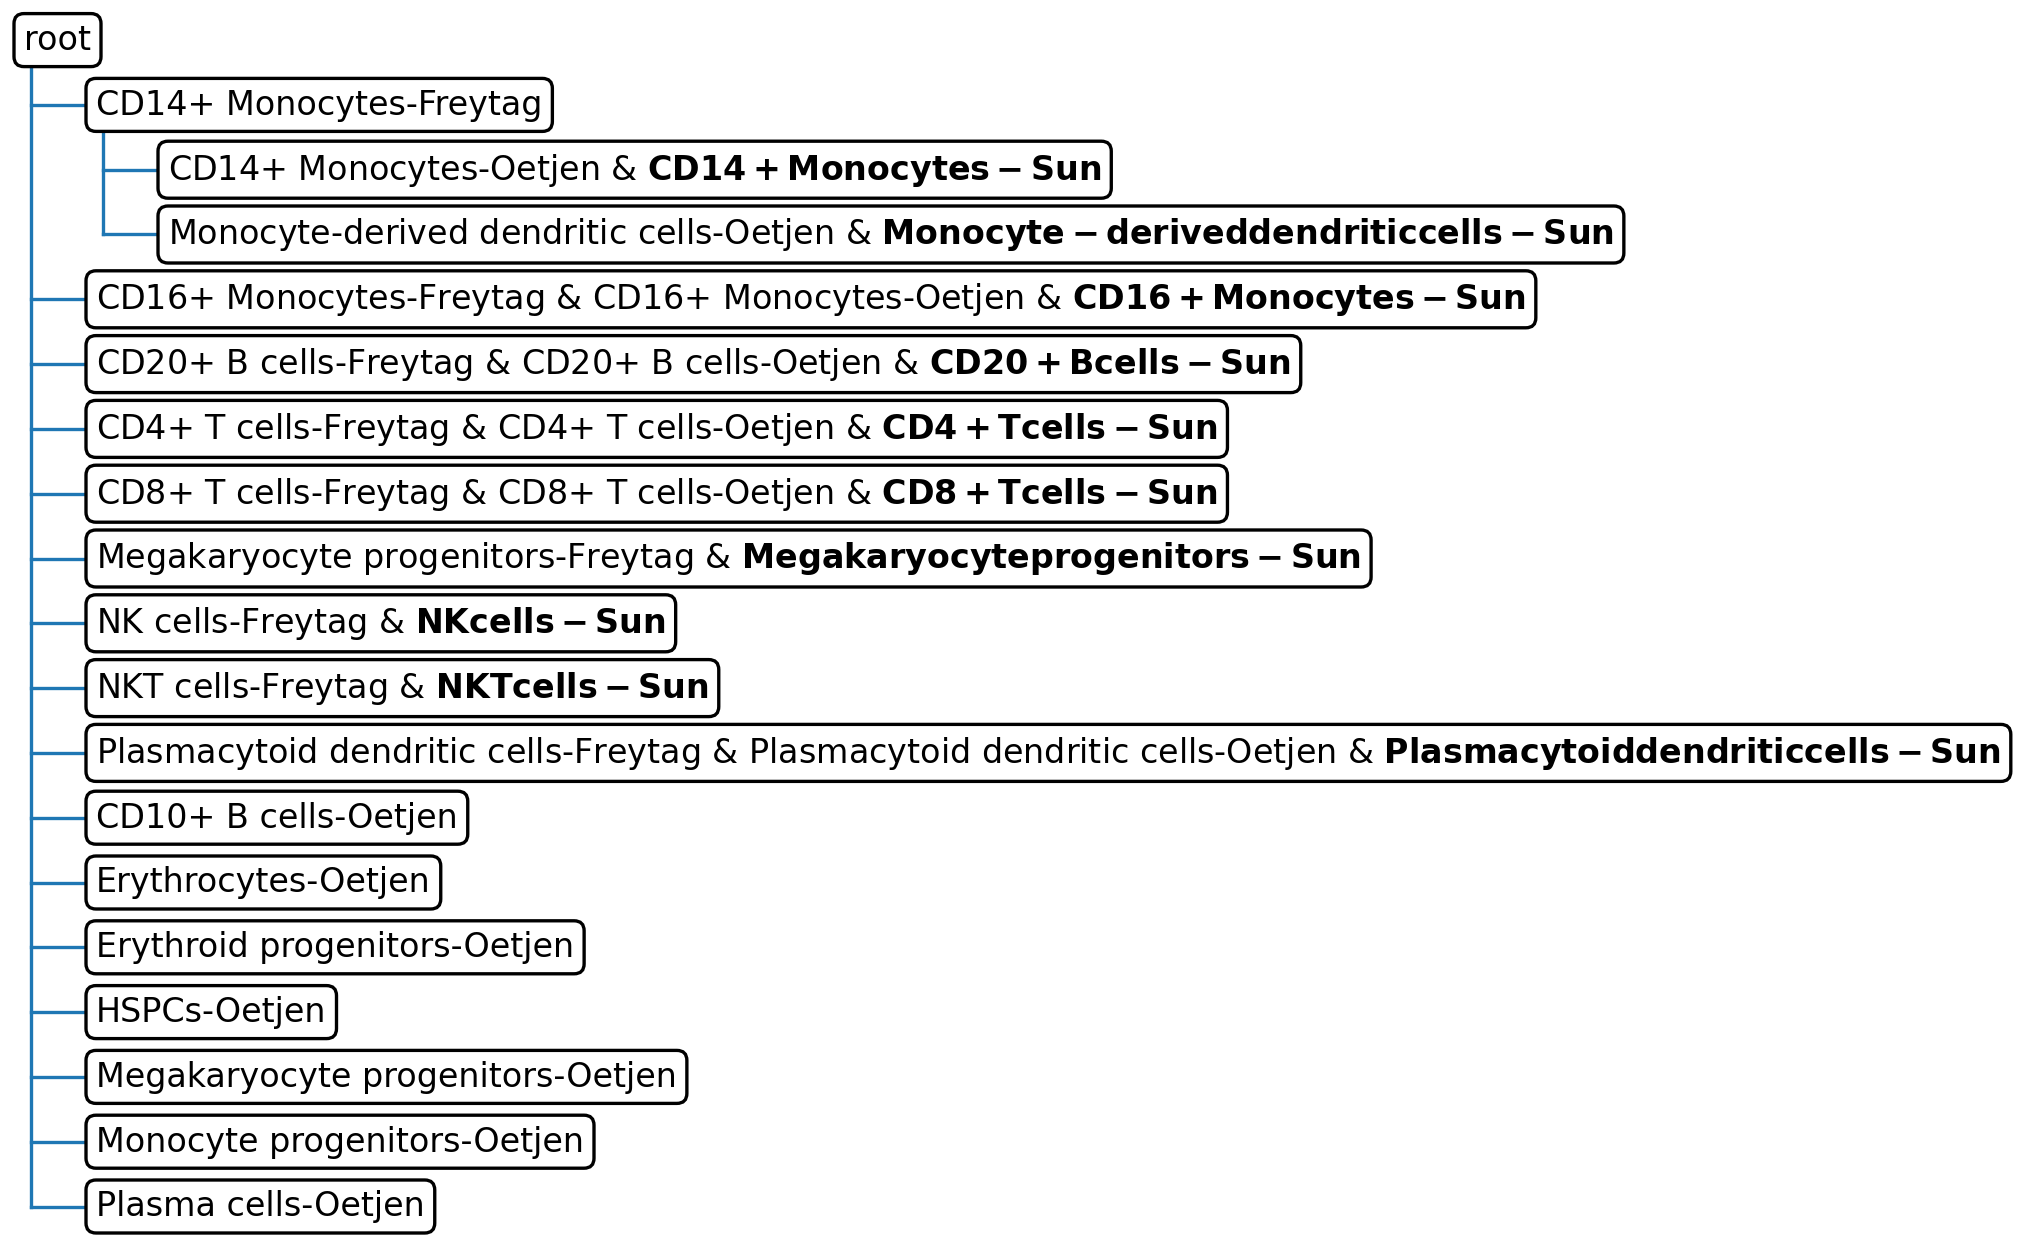

In [4]:
# scHPL prefers FAISS when installed. Use its sklearn fallback here for a
# portable small-data tutorial (and to avoid platform-specific FAISS crashes).
import sys
sys.modules['faiss'] = None

tree_ref, mp_ref = sca.classifiers.scHPL.learn_tree(
    data=reference_latent,
    batch_key='study',
    batch_order=['Freytag', 'Oetjen', 'Sun'],
    cell_type_key='celltype_batch',
    classifier='knn',
    dynamic_neighbors=True,
    dimred=False,
    print_conf=False,
)


## Major lineages with clade highlights

For presentation figures, a simple circular tree can help emphasize lineage structure without adding node metrics. `clade_annotations` shades the branches descending from selected upper nodes with shaded sectors (similar to `ggtree::geom_hilight`). Multiple branches can share one legend label and color.


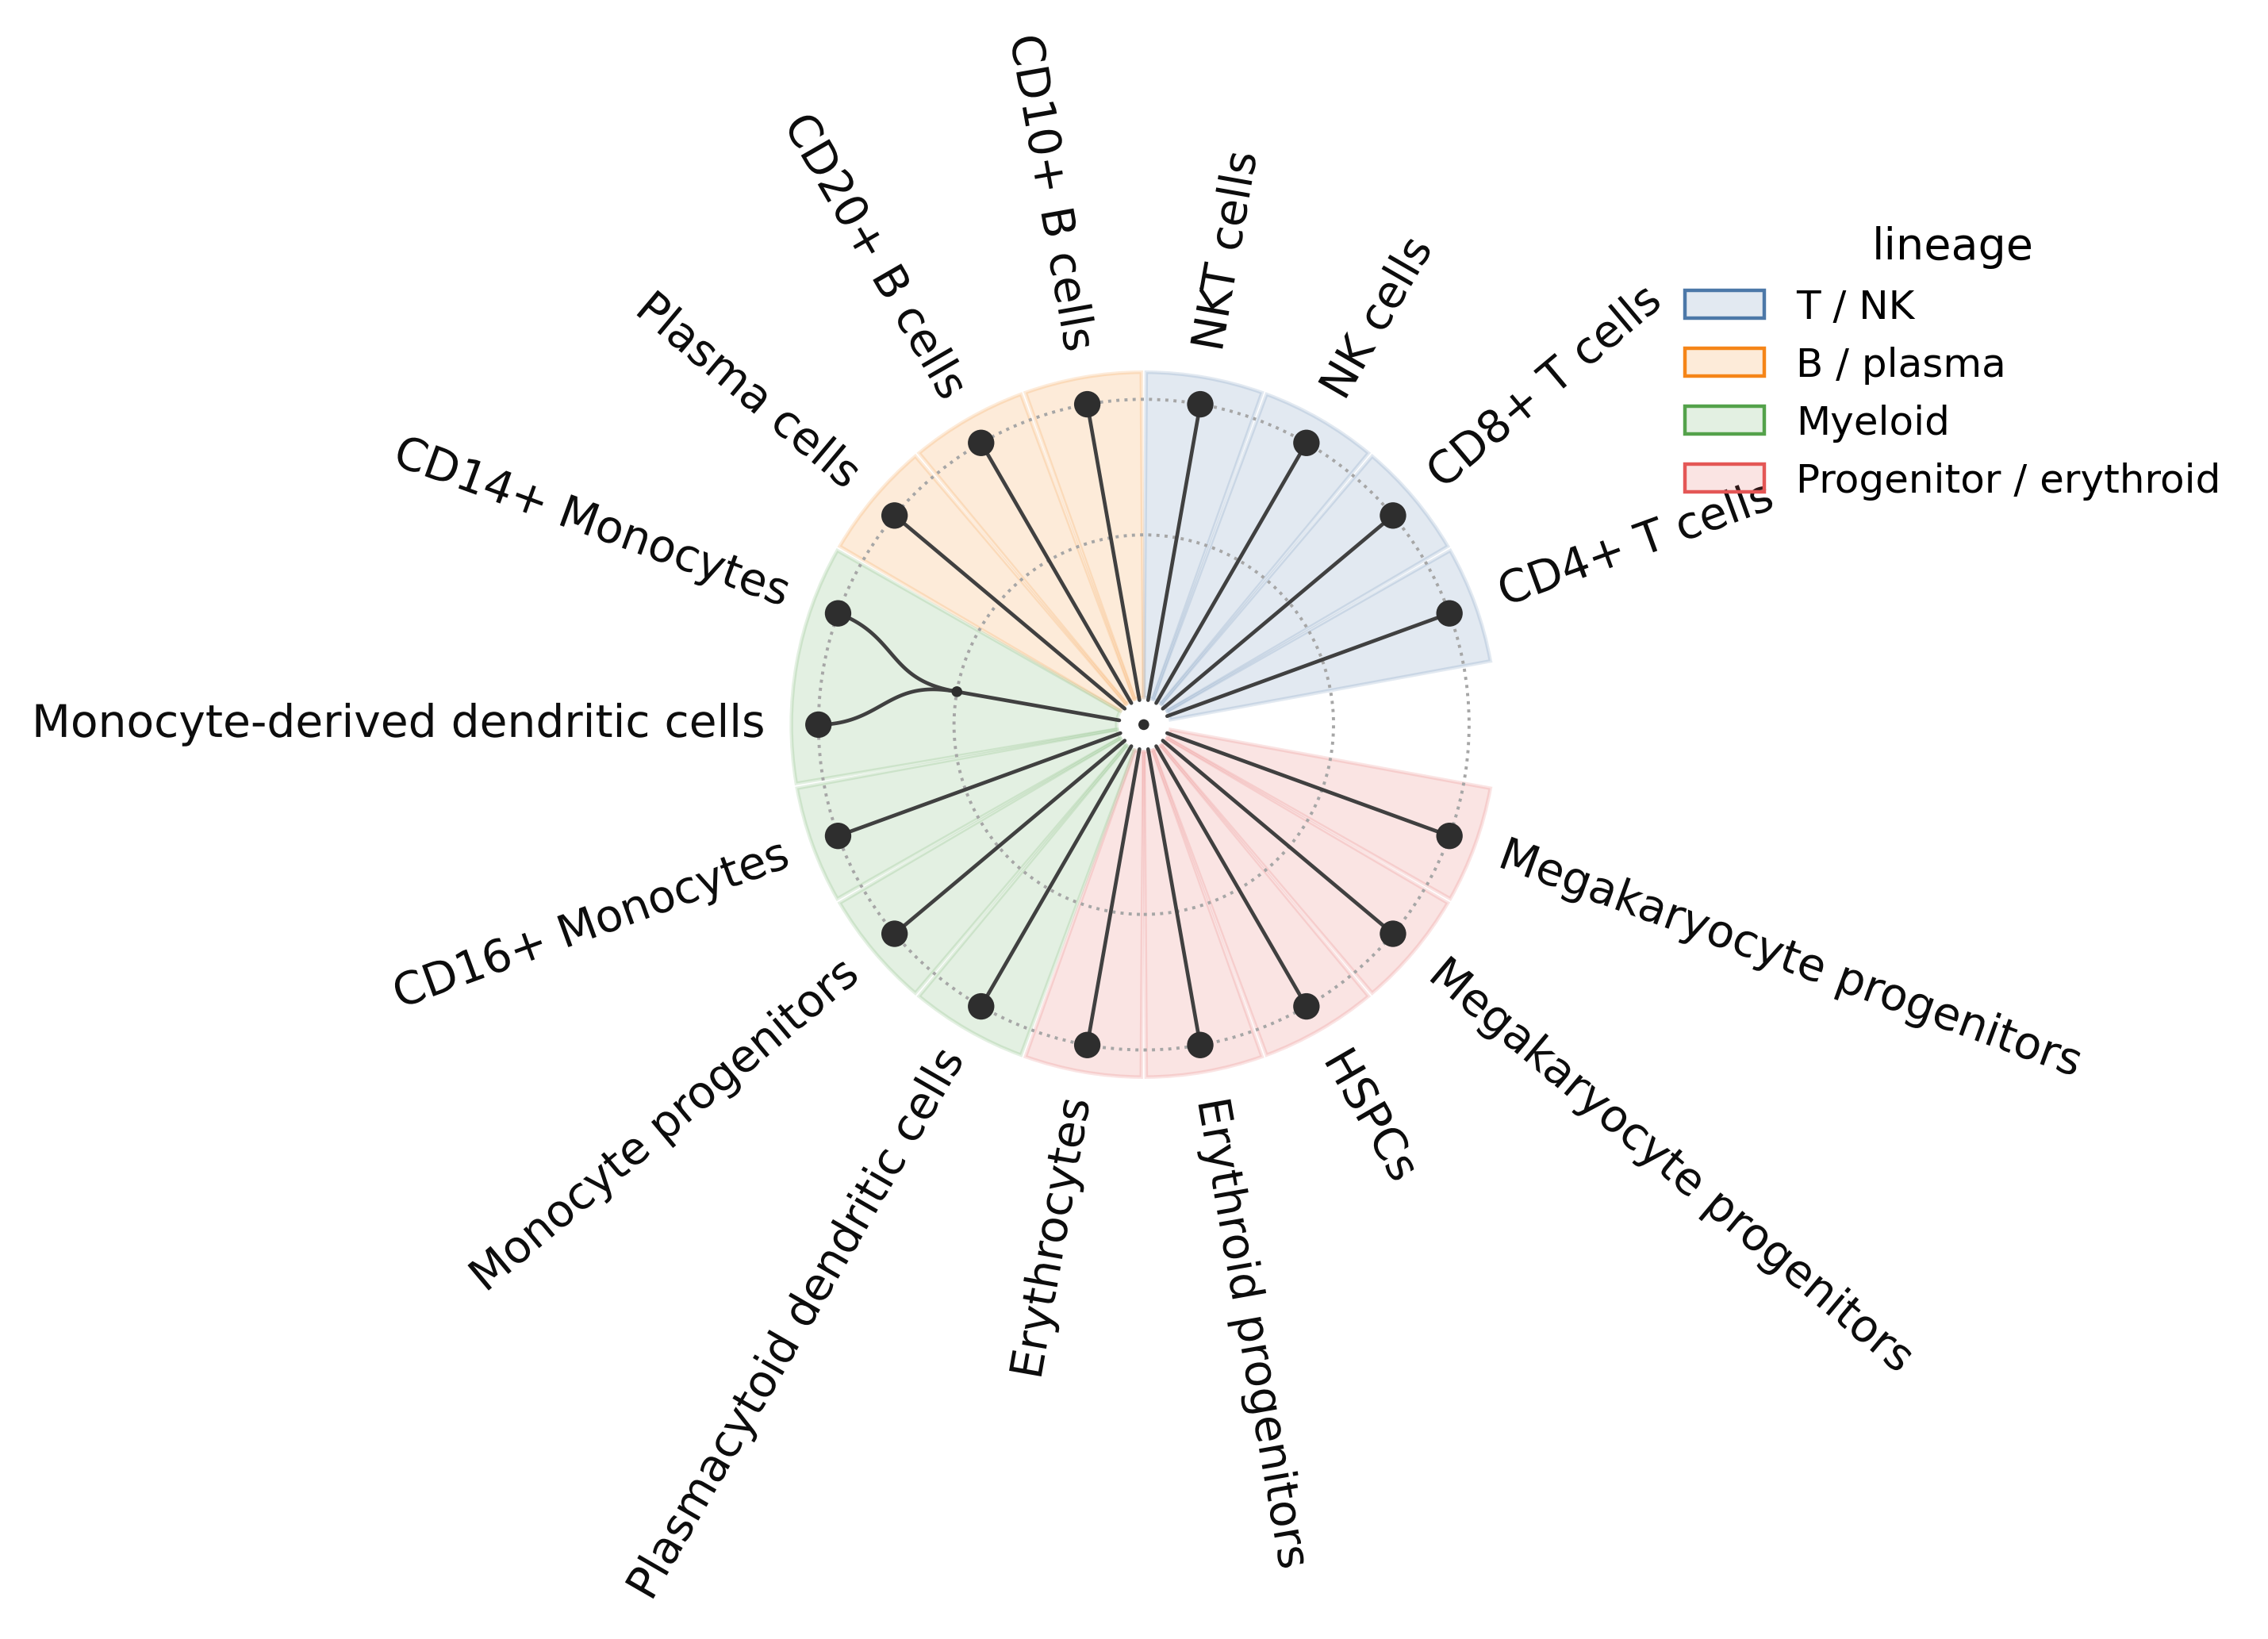

<Axes: >

In [5]:
# Find the highest homogeneous clades for each broad PBMC lineage.
lineage_rules = {
    'T / NK': (' t cells', 'nk cells', 'nkt cells'),
    'B / plasma': ('b cells', 'plasma cells'),
    'Myeloid': ('monocyte', 'dendritic'),
    'Progenitor / erythroid': ('erythro', 'hspc', 'megakaryocyte'),
}

def leaf_lineage(leaf):
    aliases = ' '.join(map(str, leaf.name)).lower()
    return next(
        (label for label, terms in lineage_rules.items()
         if any(term in aliases for term in terms)),
        None,
    )

major_lineages = {label: [] for label in lineage_rules}
def collect_homogeneous_clades(node):
    labels = {leaf_lineage(leaf) for leaf in node.get_leaves()}
    if len(labels) == 1 and None not in labels:
        major_lineages[labels.pop()].append(node)
    else:
        for child in node.descendants:
            collect_homogeneous_clades(child)

for branch in tree_ref[0].descendants:
    collect_homogeneous_clades(branch)
major_lineages = {label: nodes for label, nodes in major_lineages.items() if nodes}

lineage_colors = {
    'T / NK': '#4C78A8',
    'B / plasma': '#F58518',
    'Myeloid': '#54A24B',
    'Progenitor / erythroid': '#E45756',
}

plot_tree(
    tree_ref,
    batch_key='study',
    layout='circular',
    label_color=None,
    show_counts=False,
    node_size=36,
    linewidth=1.2,
    circular_gap=20,
    clade_annotations=major_lineages,
    clade_colors=lineage_colors,
)


## Sideways and circular layouts

`layout='horizontal'` is best for reading labels: leaves share a right margin with fixed `n` / `D` columns. `layout='circular'` is an overview: tier rings, optional outer-leaf alignment, and `color='n'` uses log1p so small populations stay visible.


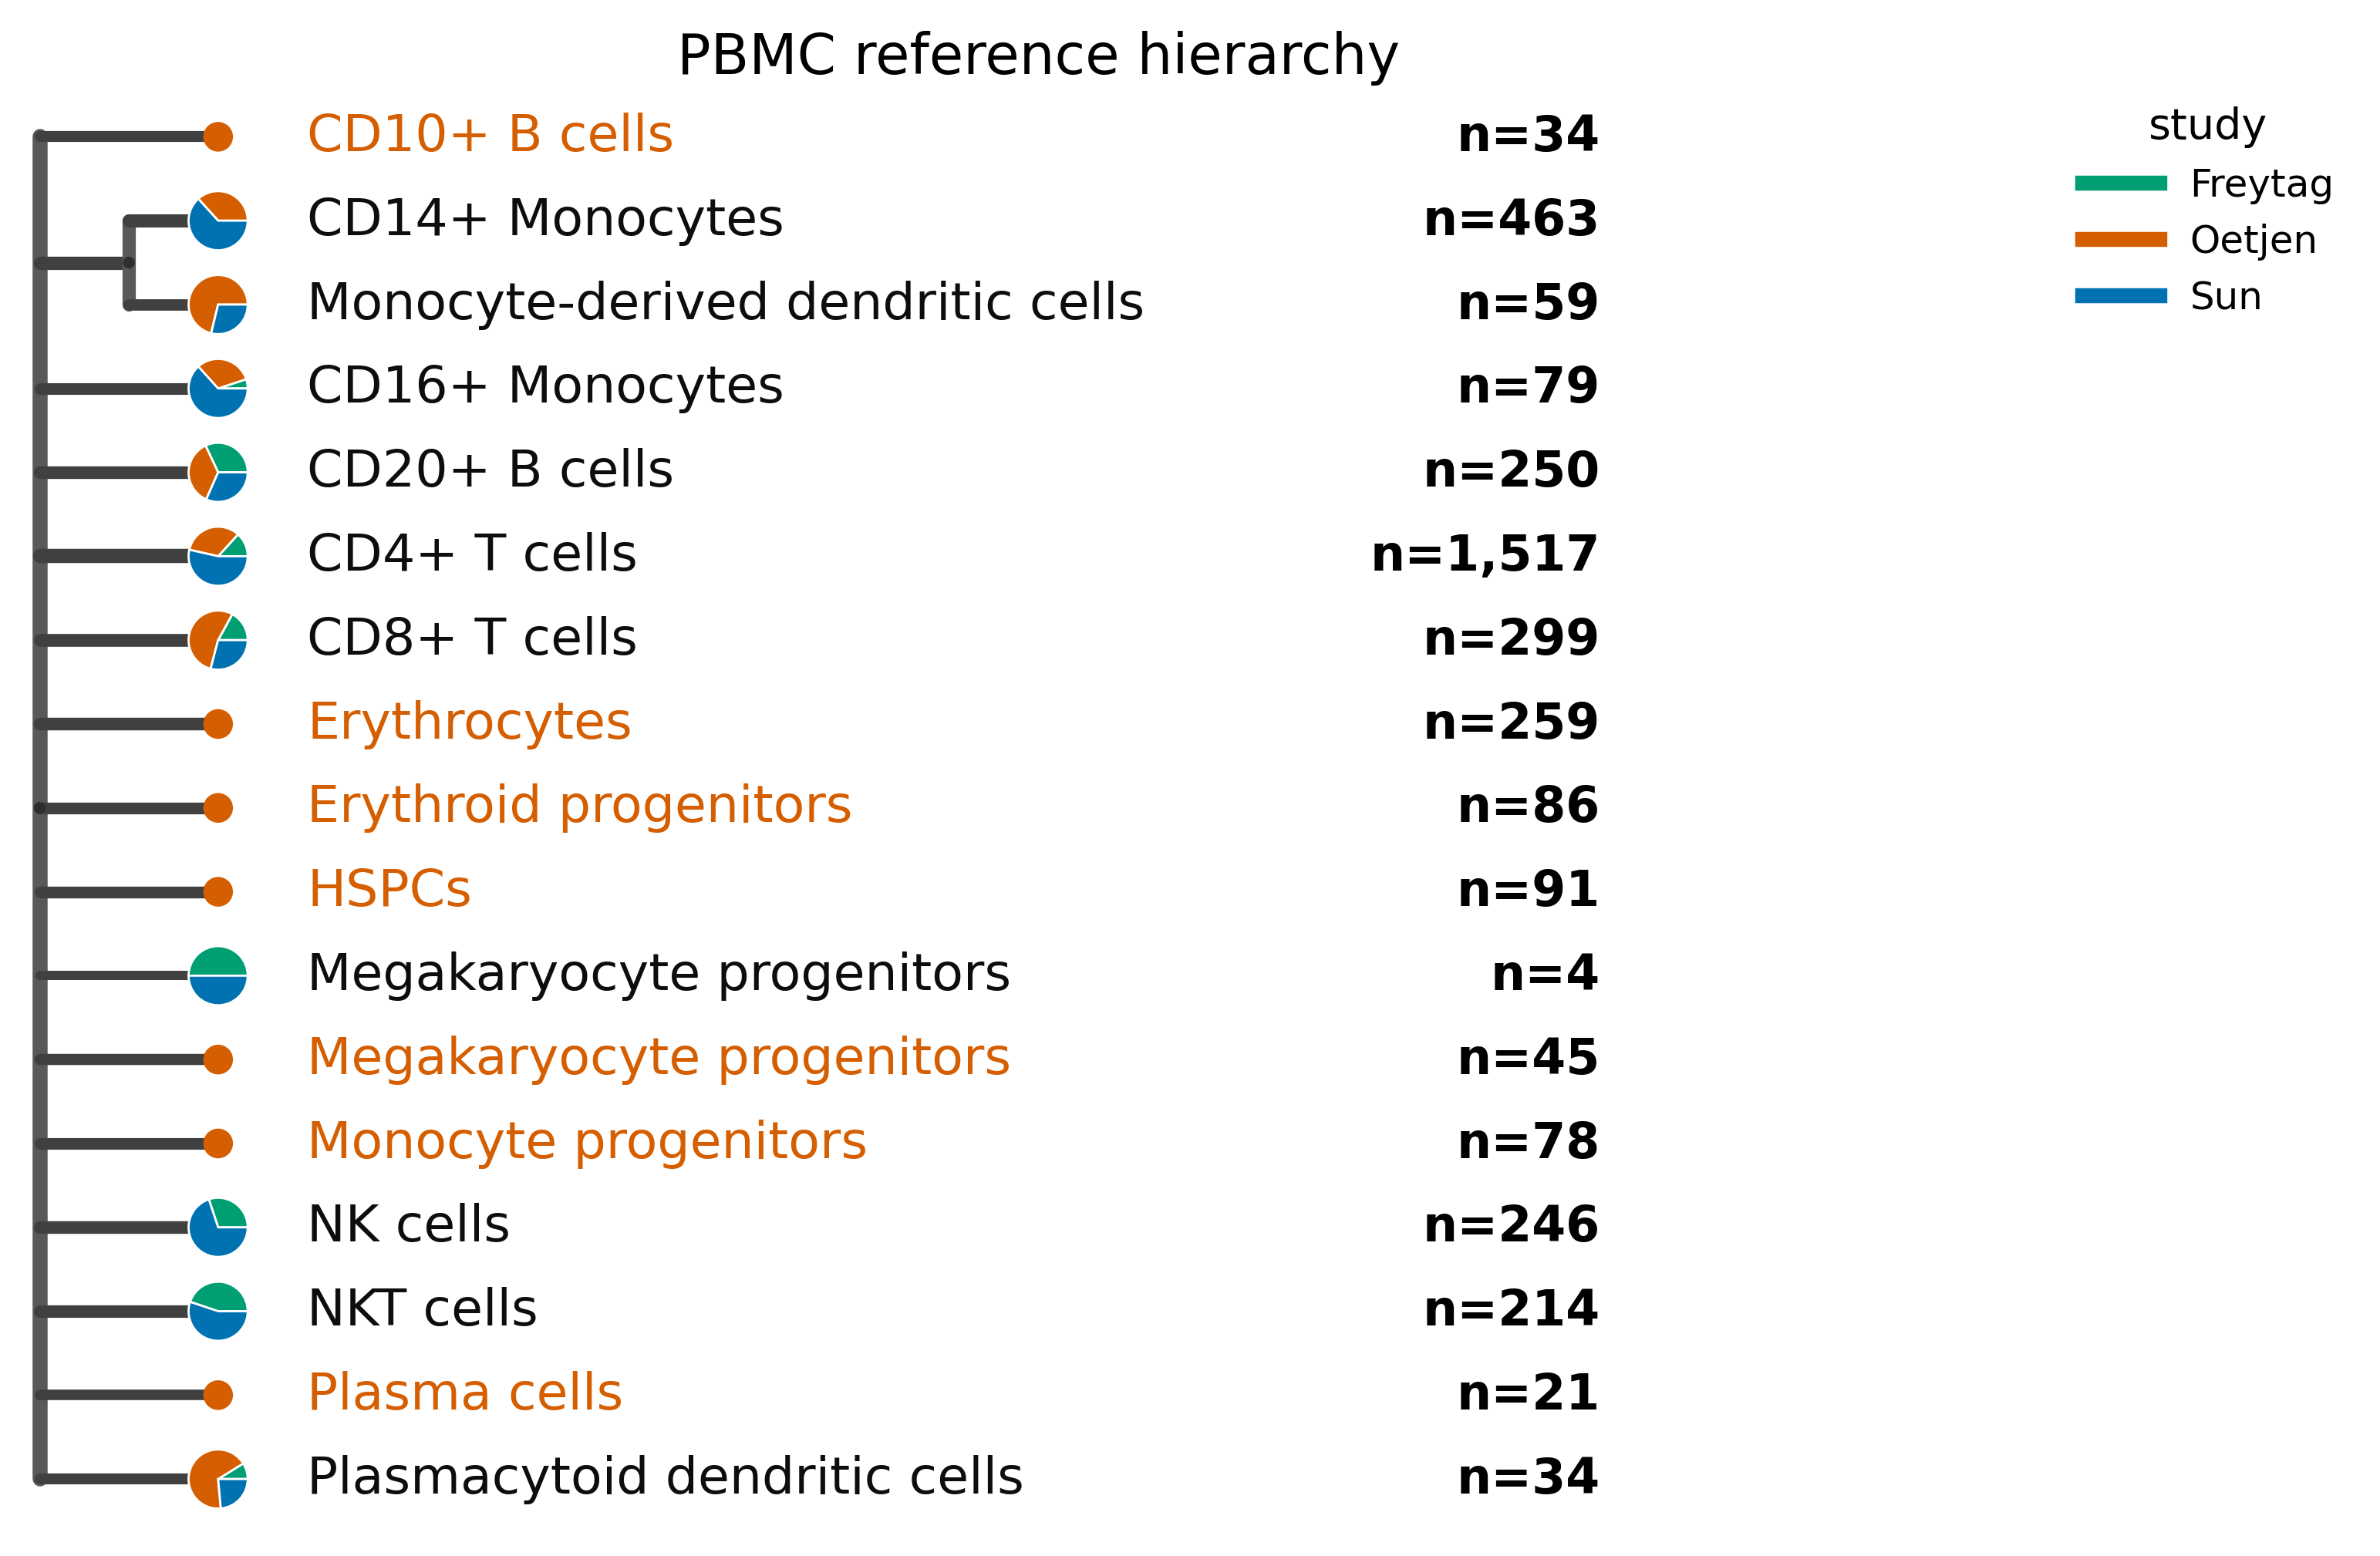

<Axes: title={'center': 'PBMC reference hierarchy'}>

In [6]:
# Defaults: short cladogram, study-colored leaf names (suffixes stripped), legend.
plot_tree(
    tree_ref,
    adata=reference_latent,
    cell_type_key='celltype_batch',
    batch_key='study',
    layout='horizontal',
    show_counts=True,
    title='PBMC reference hierarchy',
)


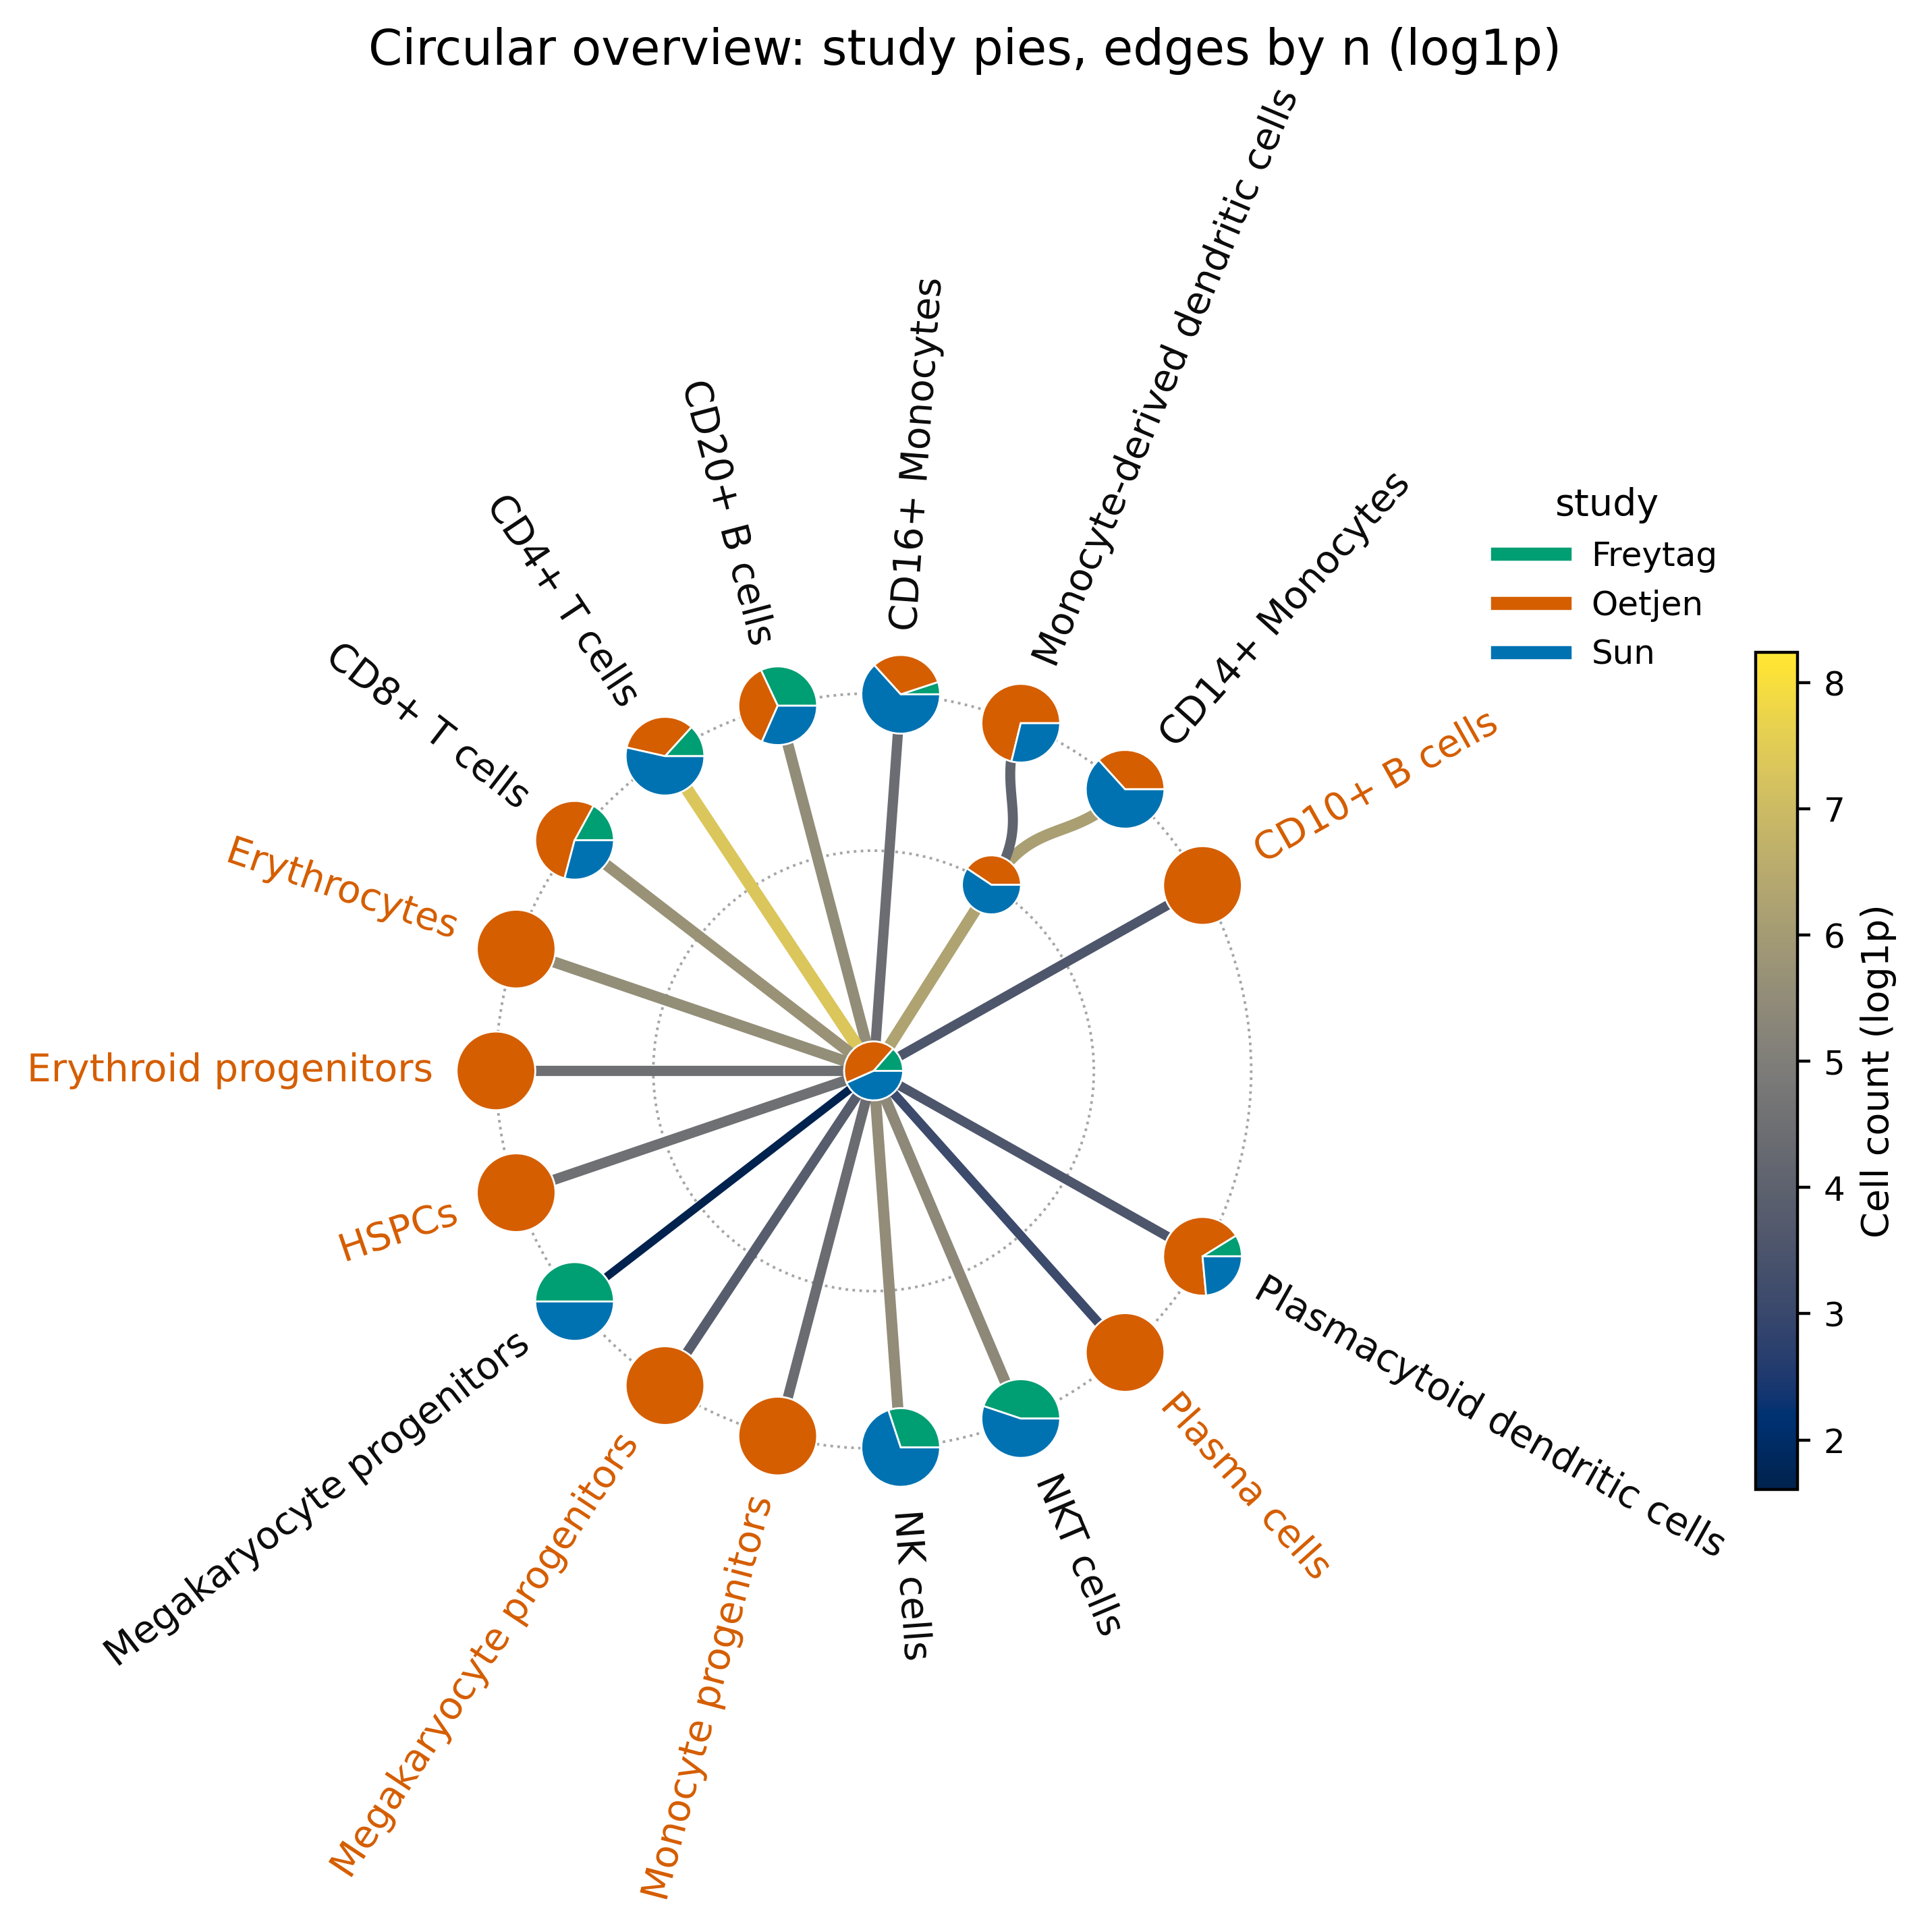

<Axes: >

In [7]:
plot_tree(
    tree_ref,
    adata=reference_latent,
    cell_type_key='celltype_batch',
    batch_key='study',
    layout='circular',
    color='n',
    pie='study',
    show_counts=False,
    title='Circular overview: study pies, edges by n (log1p)',
)


## Node and branch color, labels, composition

Node and edge color accept `'n'`, `'diversity'`, or an `adata.obs` column. Horizontal layouts use non-crossing rectangular cladogram edges and alphabetically group sibling labels by default (`order_by='label'`; use `'n'` for size order). Empty branches are grey.

With `batch_key`, the restrained default keeps branches neutral and puts study metadata at the tips:
- **Leaf names** are study-colored with `-Study` suffixes stripped (`label_color='auto'`)
- **Multi-study leaves** get circular study pies; single-study leaves stay solid
- Repeated aliases collapse to one short cell-type name
- Internals stay tiny; leaves carry the visual weight

Set `edge_color='study'` when branch color is useful, or pass `pie='study'` for a full composition overview: circular layouts pie every node, horizontal layouts pie the leaves.


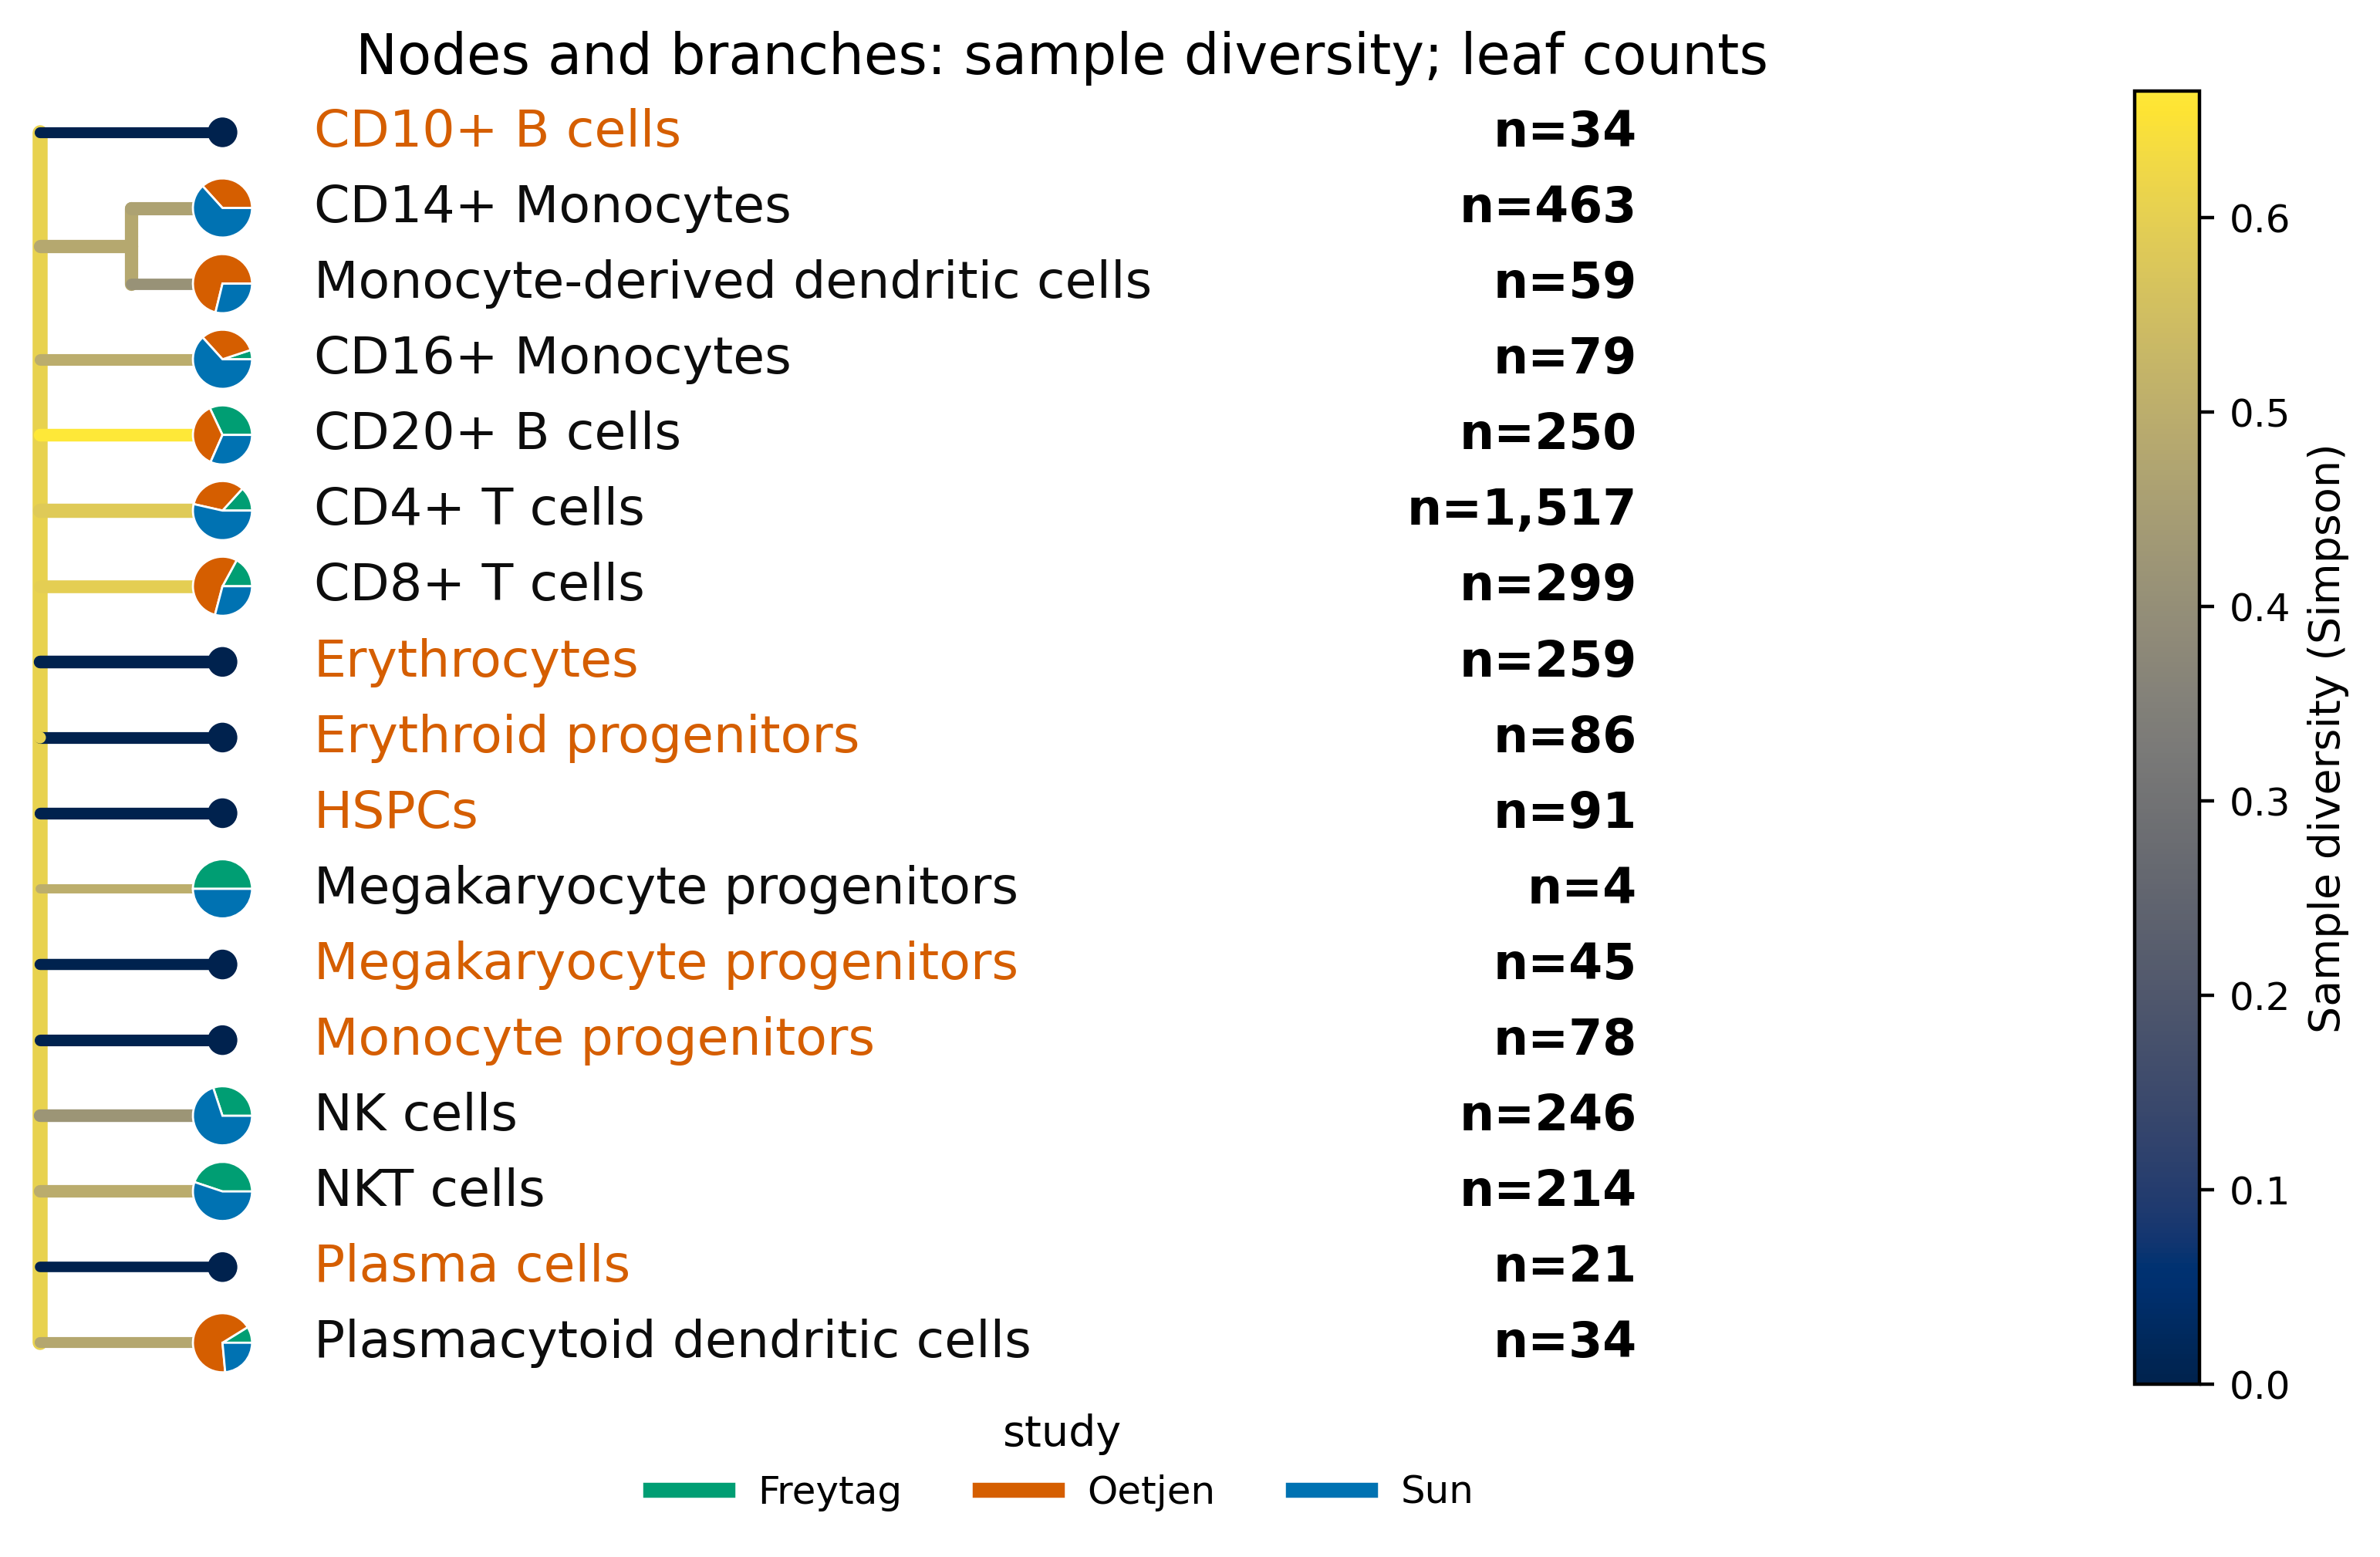

<Axes: title={'center': 'Nodes and branches: sample diversity; leaf counts'}>

In [8]:
plot_tree(
    tree_ref,
    adata=reference_latent,
    cell_type_key='celltype_batch',
    batch_key='study',
    layout='horizontal',
    color='diversity',
    edge_color='diversity',
    show_counts=True,
    title='Nodes and branches: sample diversity; leaf counts',
)


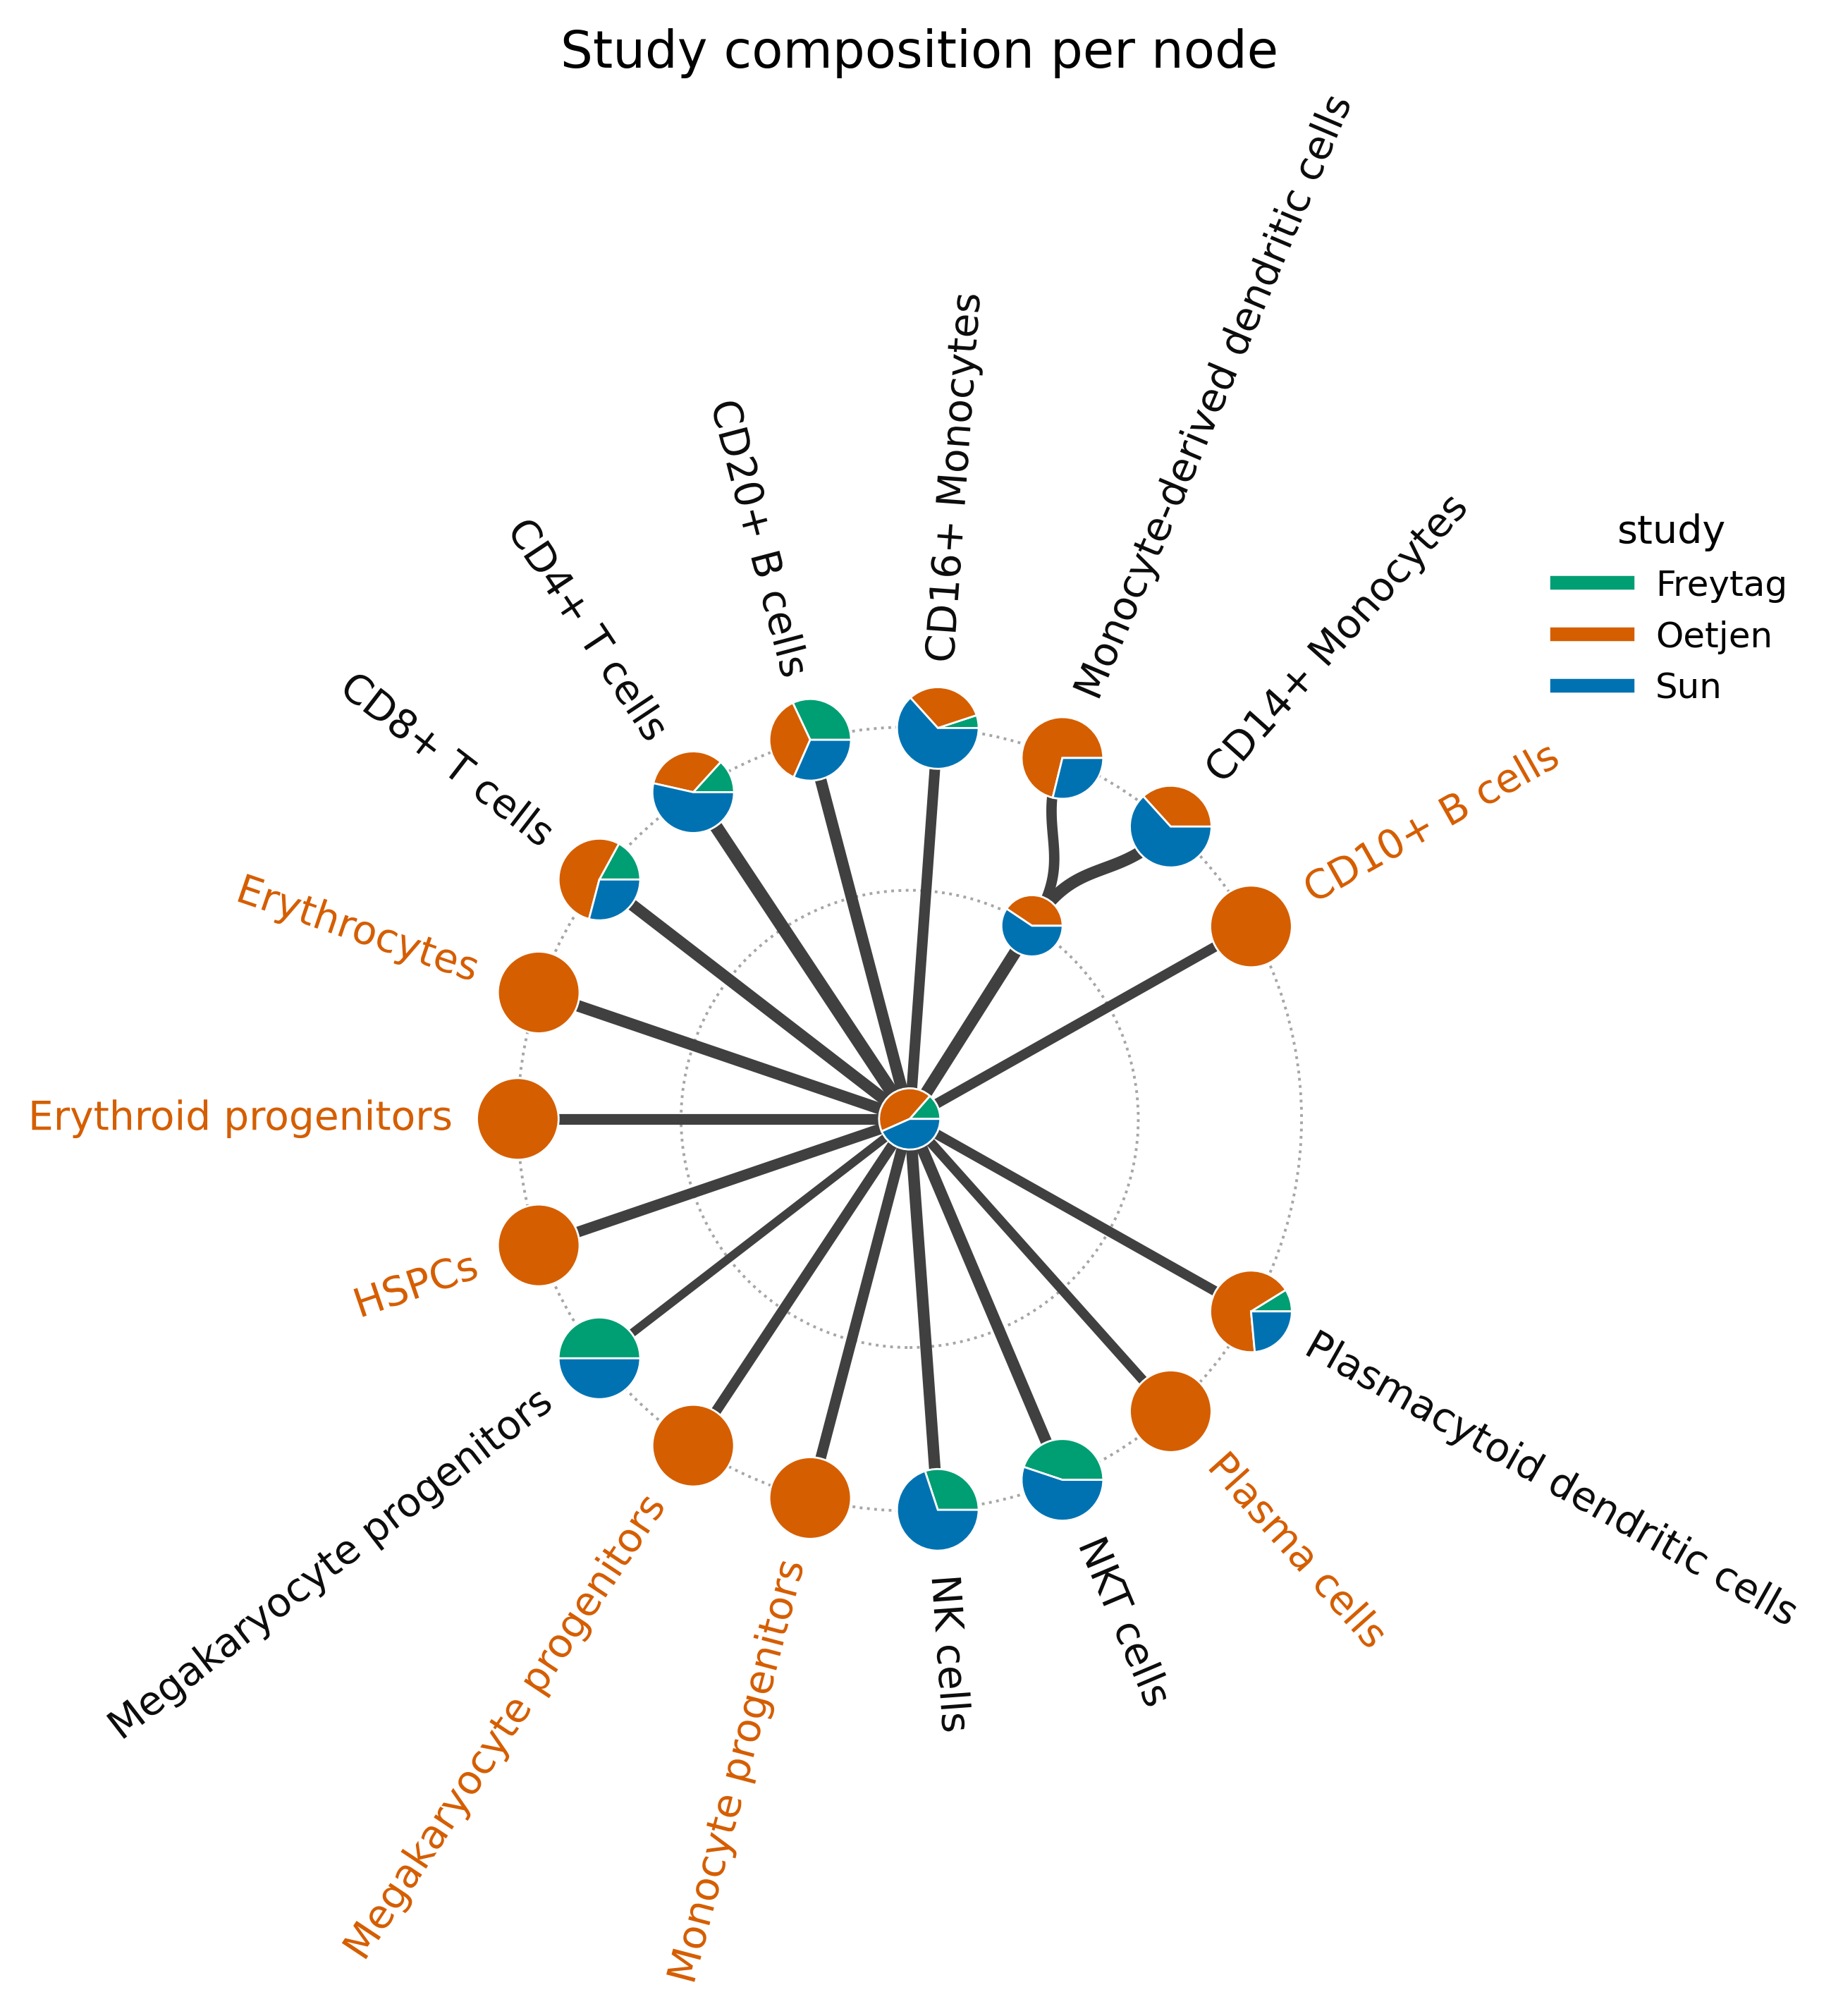

<Axes: >

In [9]:
plot_tree(
    tree_ref,
    adata=reference_latent,
    cell_type_key='celltype_batch',
    batch_key='study',
    layout='circular',
    pie='study',
    show_counts=False,
    title='Study composition per node',
)


## Global scHPL rejection thresholds

kNN scHPL learns a global nearest-neighbor distance threshold and a global reconstruction-error threshold on the root classifier. These are model-level diagnostics, not per-node quantities, so report them directly rather than coloring every branch.

In [10]:
root = tree_ref[0]
print(f'Global kNN distance rejection threshold: {root.get_maxDist():.3f}')
print(f'Global reconstruction-error threshold: {root.get_RE():.3f}')


Global kNN distance rejection threshold: 1.657
Global reconstruction-error threshold: 1.701


## Query mapping confidence

Apply surgery for the 10X query and predict labels with the trained kNN hierarchy. This is where a tree overlay is useful in the existing pipeline: node and branch color show mean prediction probability for accepted query cells, while counts show where the query mapped. Rejected cells are summarized separately because they have no accepted reference branch.

In [11]:
target_adata = target_adata[:, source_adata.var_names].copy()
model = sca.models.SCVI.load_query_data(
    target_adata,
    ref_path,
    freeze_dropout=True,
)
model.train(max_epochs=25)

query_latent = sc.AnnData(model.get_latent_representation())
query_latent.obs['cell_type'] = target_adata.obs['final_annotation'].tolist()
query_latent.obs['batch'] = target_adata.obs['batch'].tolist()
query_latent.obs['study'] = '10X'

query_pred, query_prob = sca.classifiers.scHPL.predict_labels(
    query_latent.X, tree=tree_ref
)
query_latent.obs['scHPL_pred'] = np.asarray(query_pred, dtype=str)
query_latent.obs['scHPL_prob'] = np.asarray(query_prob, dtype=float).reshape(-1)
query_latent.obs['rejected'] = query_latent.obs['scHPL_pred'].str.contains(
    'Reject', case=False, regex=True
).astype(float)


INFO     File ref_model/model.pt already downloaded                                                                


INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Epoch 25/25: 100%|█| 25/25 [00:03<00:00,  7.71it/s, v_num=1, train_loss=1.27e+3]

INFO: `Trainer.fit` stopped: `max_epochs=25` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|█| 25/25 [00:03<00:00,  8.02it/s, v_num=1, train_loss=1.27e+3]


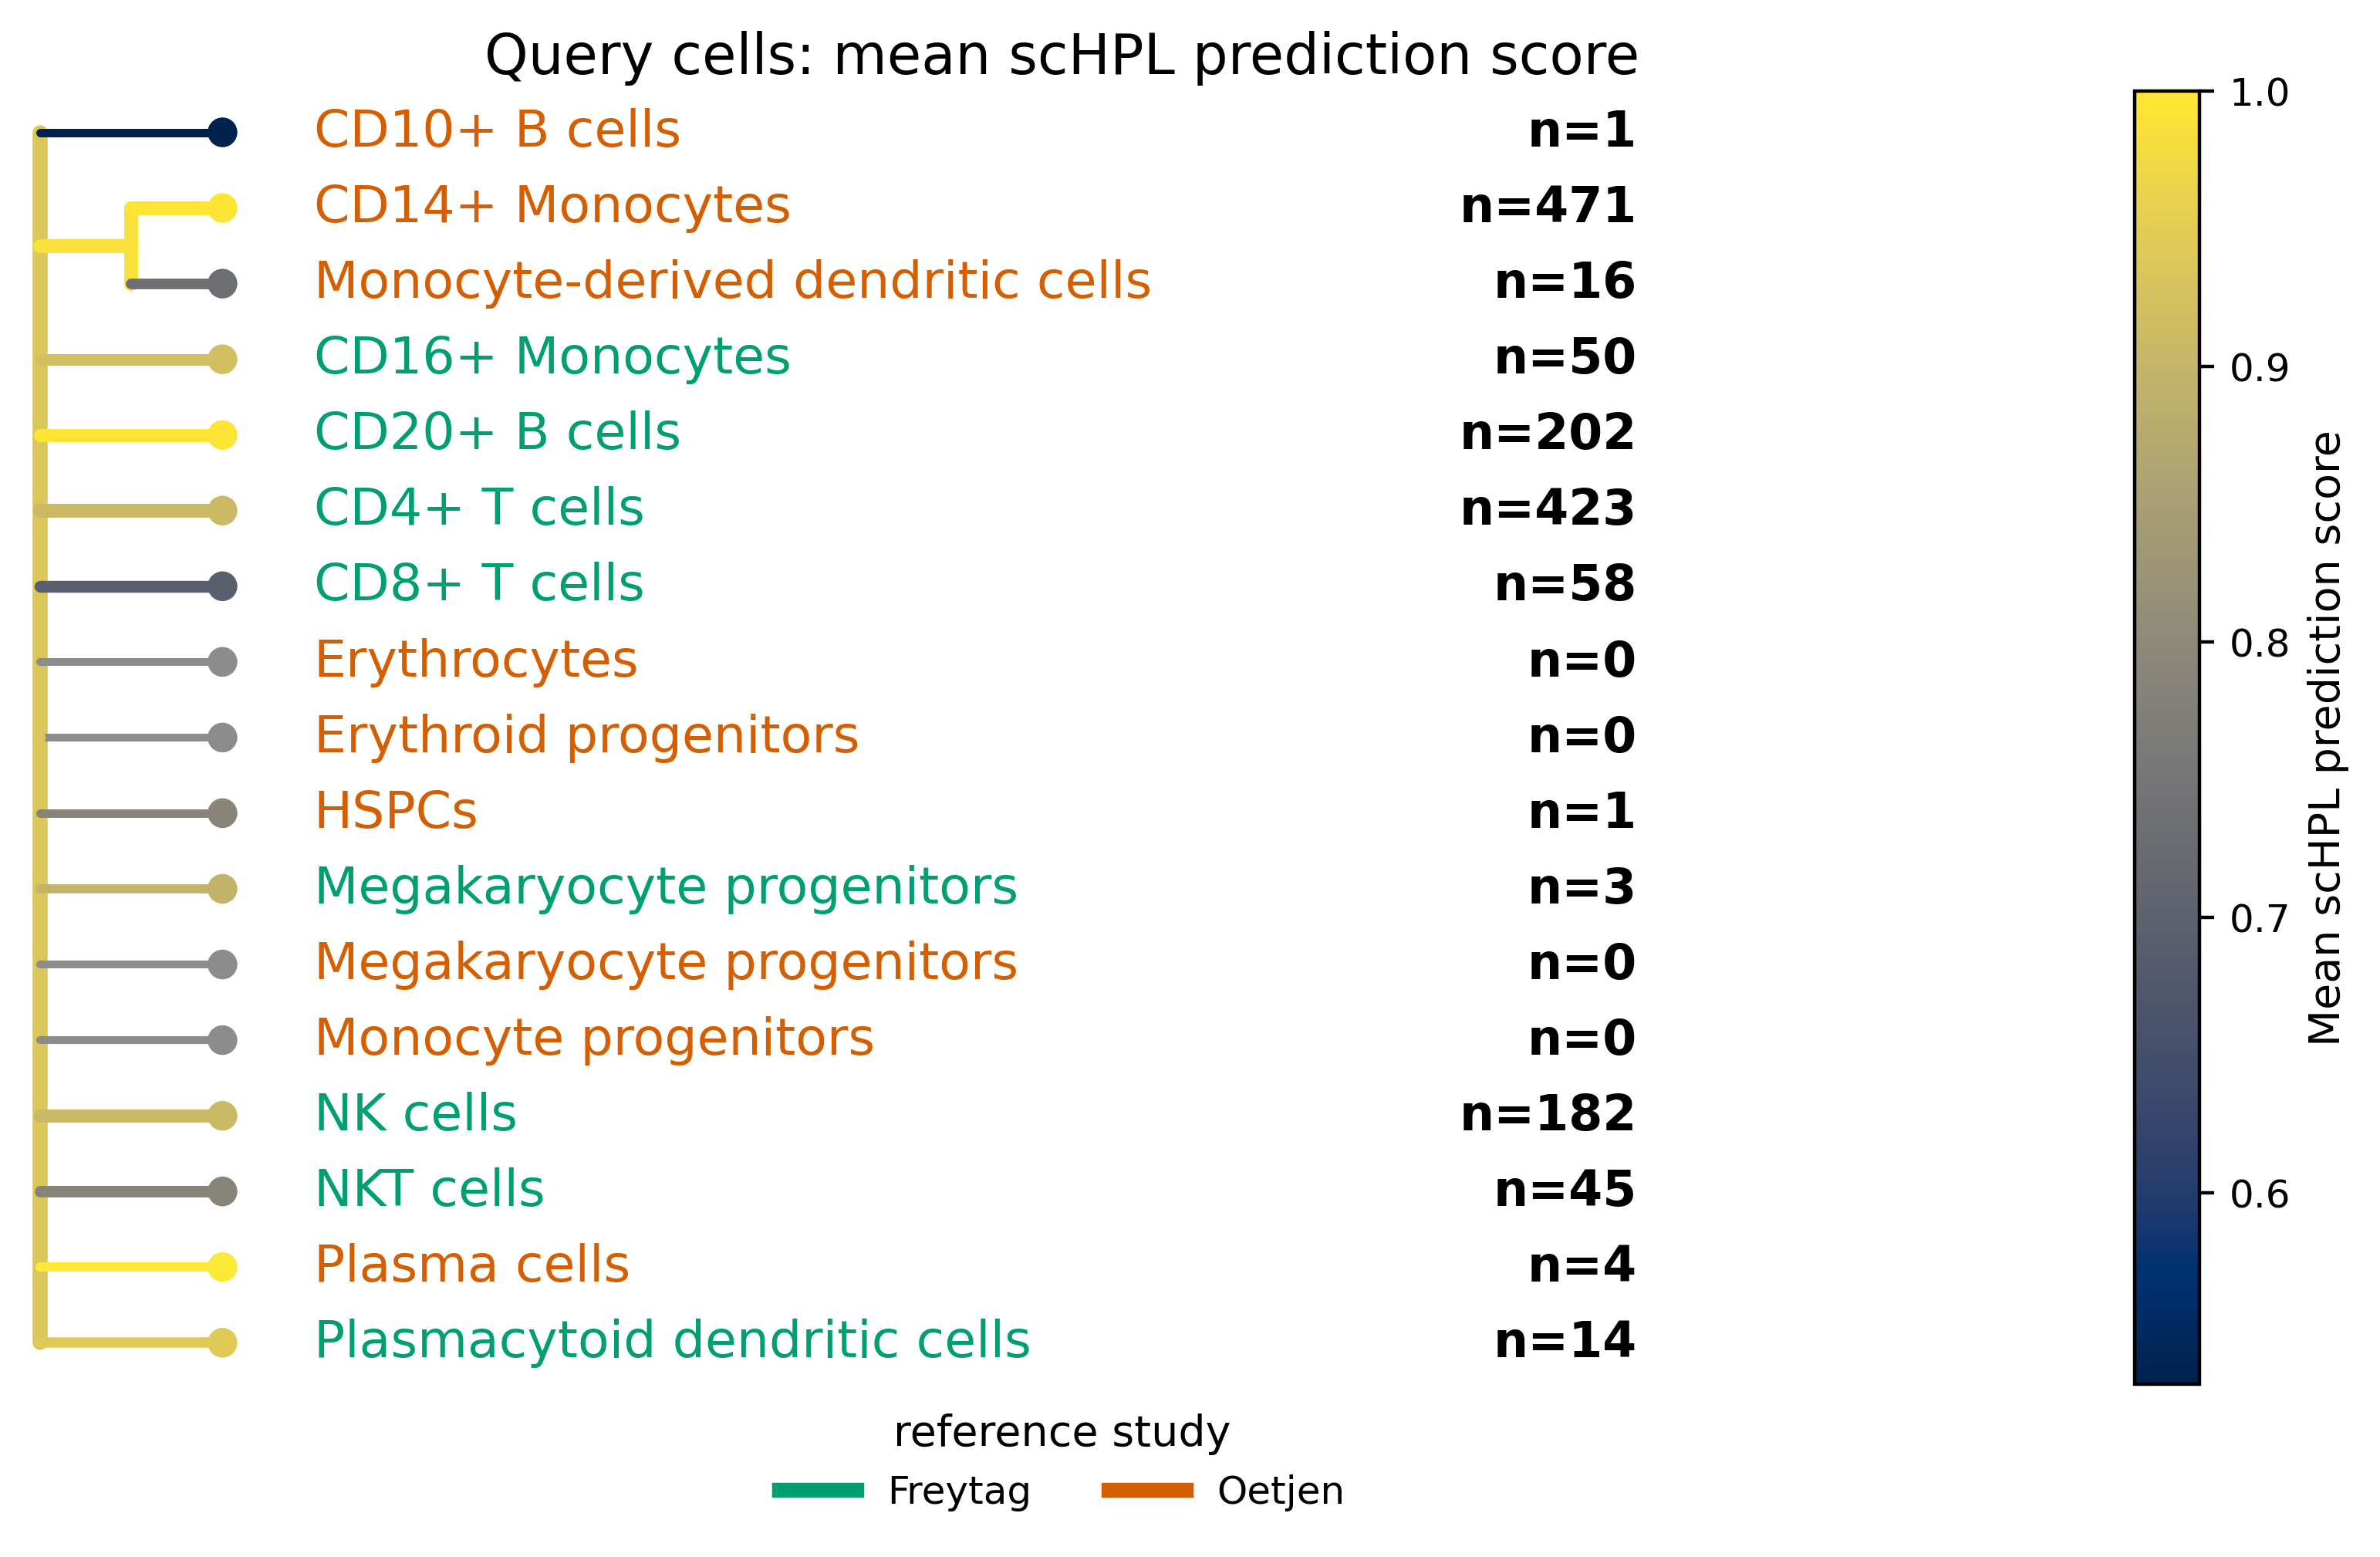

<Axes: title={'center': 'Query cells: mean scHPL prediction score'}>

In [12]:
# Map accepted predictions onto the reference tree; rejected cells are excluded.
query_accepted = query_latent[~query_latent.obs['rejected'].astype(bool)].copy()
query_accepted.obs['reference_study'] = (
    query_accepted.obs['scHPL_pred'].str.rsplit('-', n=1).str[-1]
)

plot_tree(
    tree_ref,
    adata=query_accepted,
    cell_type_key='scHPL_pred',
    batch_key='reference_study',
    layout='horizontal',
    color='scHPL_prob',
    edge_color='scHPL_prob',
    show_counts=True,
    title='Query cells: mean scHPL prediction score',
)


In [13]:
n_rejected = int(query_latent.obs['rejected'].sum())
print(
    f'Rejected query cells: {n_rejected:,} / {query_latent.n_obs:,} '
    f'({n_rejected / query_latent.n_obs:.1%})'
)


Rejected query cells: 16 / 1,500 (1.1%)
